<a href="https://colab.research.google.com/github/mili189/ASK2026_Semiconductor_FDC/blob/main/%EC%A0%84%EC%B2%98%EB%A6%AC_%EC%B6%94%EB%A1%A0%EA%B0%9C%EC%84%A0_LOF_iF_260222.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
'''
l29/31/33 통합전처리코드
by 성재 (260221)
'''



#1. 드라이브 연결

from google.colab import drive
import os

drive.mount('/content/drive')

#2. 파라미터 설정, 데이터 로드, 데이터셋 분리
#모든 실험을 통합하여 데이터셋 구성

# ==========================================
# 1. 라이브러리 및 환경 설정
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import os
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. 통합 데이터 전처리 (Unified Dataset)
# ==========================================
file_path = "/content/drive/MyDrive/2026Conv_FDC/MACHINE_Data.xlsx"
if os.path.exists(file_path):
    df = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)
else:
    df = pd.DataFrame()

sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):
    data_values = df_target[sensor_cols].values
    if is_train:
        if scaler is None: scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        data_scaled = scaler.transform(data_values)

    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences, all_wafer_ids = [], []
    for wafer in df_scaled[wafer_col].unique():
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values
        if len(wafer_data) < seq_len: continue
        for i in range(len(wafer_data) - seq_len + 1):
            all_sequences.append(wafer_data[i : i + seq_len])
            all_wafer_ids.append(wafer)

    if len(all_sequences) == 0: return np.array([]), np.array([]), scaler
    return np.array(all_sequences), np.array(all_wafer_ids), scaler



# --- 데이터 통합 및 분할 ---
datasets = {}
target_experiments = ['l29', 'l31', 'l33']
SEQ_LEN = 32
TRAIN_RATIO = 0.7

print(f"🚀 Creating Unified Dataset from: {target_experiments}")

# 통합 데이터 필터링
combined_mask = df['Wafer_ID'].str.contains('|'.join(target_experiments), case=False, na=False)
combined_df = df[combined_mask]

# ID 셔플 및 분할
all_normal_ids = combined_df[combined_df['Label'] == 'Normal']['Wafer_ID'].unique()
all_fault_ids = combined_df[combined_df['Label'] == 'Fault']['Wafer_ID'].unique()

np.random.seed(42)
np.random.shuffle(all_normal_ids)

n_train = int(len(all_normal_ids) * TRAIN_RATIO)
train_ids = all_normal_ids[:n_train]
test_norm_ids = all_normal_ids[n_train:]

# 데이터프레임 분할
df_train = combined_df[combined_df['Wafer_ID'].isin(train_ids)]
df_test_norm = combined_df[combined_df['Wafer_ID'].isin(test_norm_ids)]
df_test_fault = combined_df[combined_df['Wafer_ID'].isin(all_fault_ids)]

# 시퀀스 생성
X_train, ids_train, global_scaler = create_sequences_with_ids(df_train, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True)
X_test_norm, ids_test_norm, _ = create_sequences_with_ids(df_test_norm, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)
X_test_fault, ids_test_fault, _ = create_sequences_with_ids(df_test_fault, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)

# 사용자가 제공한 get_data_loaders 함수가 작동하도록 딕셔너리에 저장
datasets['Unified'] = {
    'X_train': X_train,
    'X_test_norm': X_test_norm,
    'ids_test_norm': ids_test_norm,
    'X_test_fault': X_test_fault,
    'ids_test_fault': ids_test_fault
}
print("✅ Unified Dataset Prepared.")

#3. 함수 정의

# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train).to(device)
    test_norm_tensor = torch.FloatTensor(X_test_norm).to(device)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault).to(device)
    else:
        test_fault_tensor = torch.FloatTensor([]).to(device)

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance(model_name, exp_id, scores, labels):
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * recall * precision / (recall + precision)
    f1_scores = np.nan_to_num(f1_scores)

    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    best_thresh = thresholds[best_idx]

    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary")
    print(f"   - AUROC         : {roc_auc:.4f}")
    print(f"   - Best F1-Score : {best_f1:.4f}")
    print(f"   - Best Threshold: {best_thresh:.6f}")

    visualize_results(model_name, exp_id, scores, labels, best_thresh)
    return roc_auc, best_f1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
🚀 Creating Unified Dataset from: ['l29', 'l31', 'l33']
✅ Unified Dataset Prepared.


🚀 총 19개 센서에 대해 논문 기반 CPD 분석을 시작합니다.


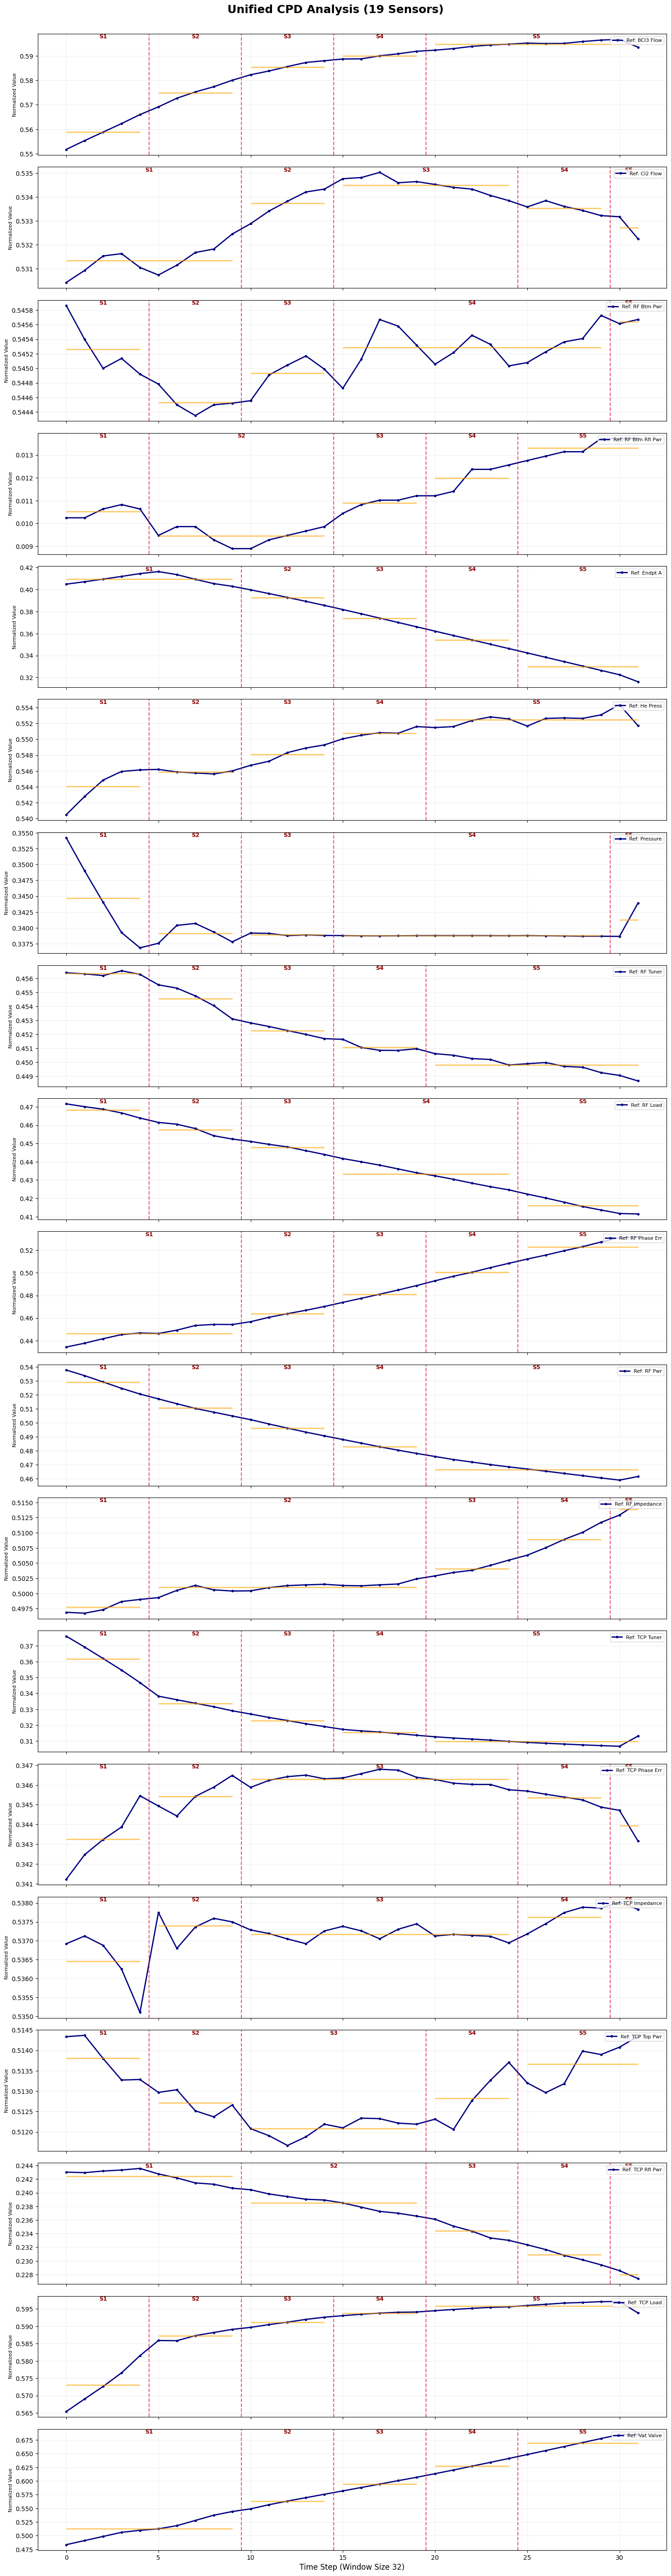

In [15]:
'''
19개 Features에 대해
Segmentation 시각화 코드
(안 돌려도 상관 없음. 뒤에서 학습/추론에서 어차피 Segmentation 실시함)
'''

# 변환점 탐지(Change Point Detection) 라이브러리 설치
!pip install ruptures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt

def analyze_all_sensors_cpd(datasets_dict, sensor_cols, n_bkps=4):
    """
    논문 방식: 19개 모든 센서 데이터를 반영하여 CPD 수행
    - 알고리즘: BinSeg (Binary Segmentation)
    - 비용 함수: CL2 (L2 Loss / Mean-shift Detection)
    """
    # 전처리된 데이터 로드 (X_train shape: [Samples, Seq_Len, Features])
    X_train = datasets_dict['Unified']['X_train']
    seq_len = X_train.shape[1]
    num_sensors = len(sensor_cols)

    print(f"🚀 총 {num_sensors}개 센서에 대해 논문 기반 CPD 분석을 시작합니다.")

    # 1. 시각화 설정 (19개 센서이므로 세로로 길게 배치)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(15, 3 * num_sensors), sharex=True)
    if num_sensors == 1: axes = [axes] # 센서가 하나일 때를 위한 예외 처리

    for i, sensor_name in enumerate(sensor_cols):
        # 2. Reference Signal 생성 (논문 기준: 정상 데이터의 평균값)
        # 모든 Wafer 샘플들의 해당 센서 값 평균을 구함 (Shape: 32,)
        series = X_train[:, :, i].mean(axis=0)

        # 3. CPD 모델 적용 (BinSeg + CL2)
        # 논문 식 (2)와 (3)에 해당
        model = rpt.Binseg(model="l2").fit(series)
        try:
            # n_bkps: 변화점 개수 (논문에서는 시각적 확인 후 조정 권장)
            breakpoints = model.predict(n_bkps=n_bkps)
        except:
            # 신호 변화가 너무 적어 탐지가 안될 경우 대응
            breakpoints = [seq_len]

        # 4. 시각화
        ax = axes[i]
        ax.plot(series, color='navy', lw=2, marker='o', markersize=3, label=f"Ref: {sensor_name}")

        # 구간별 평균선 및 경계선 표시
        start = 0
        for b_idx, end in enumerate(breakpoints):
            # 세그먼트 경계선
            if end < seq_len:
                ax.axvline(x=end - 0.5, color='crimson', linestyle='--', alpha=0.7)

            # 구간 평균 시각화 (Homogeneity 확인용)
            seg_mean = np.mean(series[start:end])
            ax.hlines(y=seg_mean, xmin=start, xmax=end-1, color='orange', lw=2, alpha=0.6)

            # 구간 번호 표시
            mid = (start + end - 1) / 2
            ax.text(mid, ax.get_ylim()[1], f"S{b_idx+1}", ha='center', va='top',
                    fontsize=9, fontweight='bold', color='darkred')
            start = end

        ax.set_ylabel("Normalized Value", fontsize=8)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.2)

    plt.xlabel("Time Step (Window Size 32)", fontsize=12)
    plt.suptitle(f"Unified CPD Analysis (19 Sensors)", fontsize=18, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.show()

# 실행: n_bkps=4는 5개의 구간을 의미합니다.
analyze_all_sensors_cpd(datasets, sensor_cols, n_bkps=4)

🚀 [Phase 1] 모델 학습 시작...
✅ 학습 완료: iF 모델이 정상 데이터의 세그먼트별 LOF 분포를 학습했습니다.

🔍 [Phase 2] 테스트 데이터 평가 시작...
📈 웨이퍼 레벨 점수 집계 중...

              CPD-LOF-IsoForest PERFORMANCE REPORT

📌 [CPD-LOF-IsoForest - Unified_Test] Wafer-Level Summary
   - AUROC         : 0.7258
   - Best F1-Score : 0.6667
   - Best Threshold: -0.073947


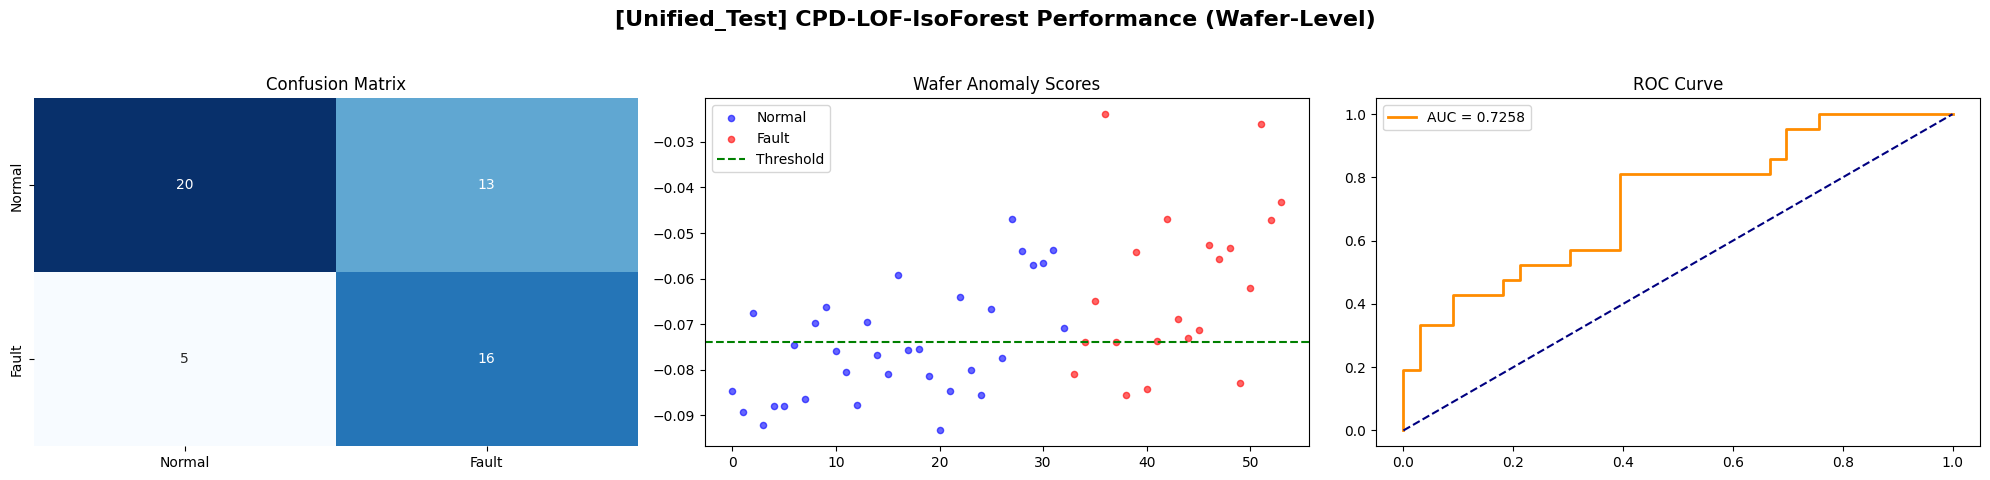

(np.float64(0.7258297258297258), np.float64(0.6666666666666666))

In [21]:
'''
학습/추론
Segmentation/LOF Score 계산/iF 모델의 LOF Score 분포 패턴 학습 및 분별이
모두 포함되어 있음
'''
!pip install ruptures
import numpy as np
import pandas as pd
import ruptures as rpt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# ==========================================
# [함수 정의] 특징 추출 및 세그먼테이션 (논문 방식)
# ==========================================

def extract_lof_features(X_data, sensor_cols, n_bkps=4, k=25, saved_bkps=None):
    """
    X_data: [Samples, Seq_Len, Features]
    saved_bkps: None이면 Train 모드(변화점 새로 계산),
                딕셔너리 값이 있으면 Test 모드(저장된 변화점 사용)
    """
    num_samples = X_data.shape[0]
    num_sensors = len(sensor_cols)
    num_segs = n_bkps + 1
    reduced_features = np.zeros((num_samples, num_sensors * num_segs))

    current_bkps = {} # Train 모드일 때 변화점을 저장할 공간

    for s_idx, sensor_name in enumerate(sensor_cols):
        # 1. 변화점(Breakpoints) 설정
        if saved_bkps is None:
            # [Train] 레퍼런스 신호(평균)를 생성하여 변화점 탐지
            ref_signal = X_data[:, :, s_idx].mean(axis=0)
            model = rpt.Binseg(model="l2").fit(ref_signal)
            breakpoints = model.predict(n_bkps=n_bkps)
            current_bkps[sensor_name] = breakpoints
        else:
            # [Test] 사전에 정의된 변화점 사용
            breakpoints = saved_bkps[sensor_name]

        # 2. 세그먼트별 LOF 점수 계산
        start = 0
        for b_idx, end in enumerate(breakpoints):
            segment_data = X_data[:, start:end, s_idx]

            # LOF 모델링
            n_neighbors = min(k, segment_data.shape[0] - 1)
            lof = LocalOutlierFactor(n_neighbors=n_neighbors)
            lof.fit(segment_data)

            # 특징 벡터에 점수 저장
            feature_idx = s_idx * num_segs + b_idx
            reduced_features[:, feature_idx] = -lof.negative_outlier_factor_
            start = end

    return reduced_features, current_bkps

# ==========================================
# [Phase 1] 모델 학습 (정상 데이터 전용)
# ==========================================

print("🚀 [Phase 1] 모델 학습 시작...")

# 1. 정상 데이터(X_train)로부터 특징 추출 및 변화점(Breakpoints) 저장
X_train_reduced, train_bkps = extract_lof_features(
    datasets['Unified']['X_train'], sensor_cols, n_bkps=4, k=25
)

# 2. Isolation Forest 학습
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42) #n_estimators: 나무 개수; 클수록 무작위성에 대한 오차가 평균화되어 안정화됨. 기존 100에서 500으로 올림
iso_forest.fit(X_train_reduced)

print("✅ 학습 완료: iF 모델이 정상 데이터의 세그먼트별 LOF 분포를 학습했습니다.")

# ==========================================
# [Phase 2] 모델 평가 (테스트 데이터셋)
# ==========================================

print("\n🔍 [Phase 2] 테스트 데이터 평가 시작...")

# 1. 테스트 데이터 특징 추출 (학습 때 저장한 train_bkps 고정 사용)
X_test_norm_reduced, _ = extract_lof_features(
    datasets['Unified']['X_test_norm'], sensor_cols, saved_bkps=train_bkps
)
X_test_fault_reduced, _ = extract_lof_features(
    datasets['Unified']['X_test_fault'], sensor_cols, saved_bkps=train_bkps
)

# 2. Isolation Forest 점수 산출 (Window-Level)
# 낮을수록 이상이므로 부호를 반전시켜 점수가 높을수록 이상함을 의미하게 함
scores_norm_win = -iso_forest.decision_function(X_test_norm_reduced)
scores_fault_win = -iso_forest.decision_function(X_test_fault_reduced)

# 3. 웨이퍼 단위 점수 집계 (사전 정의된 aggregate_wafer_scores 함수 활용)
#aggregate 스코어의 method를 max로 잡을 경우,
#비정상으로 간주하는 경우 다수 발생
#이를 해결하고자 method를 mean으로 잡아 Strict 한 정도를 낮춤 (튀는 값 있는 걸 비정상으로 감지하지 못 하도록)
print("📈 웨이퍼 레벨 점수 집계 중...")
wafer_ids_norm, wafer_scores_norm = aggregate_wafer_scores(
    scores_norm_win, datasets['Unified']['ids_test_norm'], method='mean'
)
wafer_ids_fault, wafer_scores_fault = aggregate_wafer_scores(
    scores_fault_win, datasets['Unified']['ids_test_fault'], method='mean'
)

# 4. 평가 데이터 결합 및 라벨링
final_scores = np.concatenate([wafer_scores_norm, wafer_scores_fault])
final_labels = np.concatenate([
    np.zeros(len(wafer_scores_norm)), # Normal = 0
    np.ones(len(wafer_scores_fault))  # Fault = 1
])

# 5. 최종 성능 리포트 (사전 정의된 evaluate_performance 함수 활용)
print("\n" + "="*60)
print("              CPD-LOF-IsoForest PERFORMANCE REPORT")
print("="*60)
evaluate_performance(
    model_name="CPD-LOF-IsoForest",
    exp_id="Unified_Test",
    scores=final_scores,
    labels=final_labels
)